# Plotting Training Curves — Complete Theory

## Why Visualize?

Numbers in a terminal tell you *what* happened. Plots tell you *why* and *what to do next*. A training curve lets you diagnose in seconds what would take minutes to parse from logs.

---

## The Four Plots Worth Making

**1. Loss curves** — train loss and val loss on the same graph across epochs. The gap between them tells you everything about overfitting.

**2. Accuracy curves** — same idea but for accuracy. Sometimes loss and accuracy tell different stories.

**3. Learning rate curve** — shows when the scheduler fired. Helps explain sudden changes in the loss curve.

**4. Optimizer comparison** — multiple lines on one plot, one per optimizer. Lets you visually compare convergence speed.

---

## Reading Loss Curves

``` t
Both losses decreasing together → healthy training
Train loss decreasing, val loss flat → underfitting or feature limitation  
Train loss decreasing, val loss increasing → overfitting
Both losses flat from epoch 1 → learning rate too low or model broken
Val loss lower than train loss → normal early on (you saw this)
```

---

## Matplotlib Basics You Need

```python
import matplotlib.pyplot as plt

# One plot
plt.figure(figsize=(10, 4))
plt.plot(epochs, train_losses, label='Train')
plt.plot(epochs, val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('curves.png')  # save to disk
plt.show()

# Multiple plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(...)  # left plot
axes[1].plot(...)  # right plot
```

**Import:**
```python
import matplotlib.pyplot as plt
```

---

## TODO 1: Plot Your Early Stopping Run

**Goal:** Visualize the training run from your early stopping session.

**Requirements:**
- Modify your early stopping training loop to collect `train_losses`, `val_losses`, `train_accs`, `val_accs` as lists across epochs
- After training stops, create a figure with two side-by-side subplots: loss curves and accuracy curves
- Both subplots show train and val lines with different colors
- Add labels, title, legend, grid to each
- Mark the epoch where early stopping triggered with a vertical dashed line
- Save the figure to `outputs/plots/training_curves.png`

**Hints:**
- `axes[0].axvline(x=stopped_epoch, color='red', linestyle='--', label='Early Stop')` draws a vertical line
- `plt.subplots(1, 2, figsize=(14, 5))` for side by side
- `x` axis should be epoch numbers starting from 1, not 0

---

## TODO 2: Optimizer Comparison Plot

**Goal:** Plot all three optimizers on the same graph for visual comparison.

**Requirements:**
- Use your `output1`, `output2`, `output3` from the optimizer notebook
- One plot showing val loss curves for all three optimizers across epochs
- Different color per optimizer, labeled clearly
- Title: "Optimizer Comparison — Validation Loss"
- Save to `outputs/plots/optimizer_comparison.png`

**Hints:**
- You'll need to extract the val loss list from your list-of-dicts structure: `[d['val_losses'] for d in output1]`
- `range(1, num_epochs+1)` for x axis

---

## TODO 3: Interpret Your Plots

After both plots are generated, answer these in a comment cell:
- What does your loss curve shape tell you about your model?
- At what epoch did the model stop meaningfully improving?
- Which optimizer converged fastest visually?

---

Start with TODO 1. Show me the plot output when done.

In [1]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path
import os
import sys
import json

# Check if __file__ exists (it won't in Jupyter)
try:
    current_dir = Path(__file__).parent
except NameError:
    # If in Jupyter, use the current working directory
    current_dir = Path(os.getcwd())

# Add project root to Python path
project_root = current_dir.parent.parent.parent
sys.path.insert(0, str(project_root))

from src.preprocessing.audio_utils import load_audio


# Device configuration (for your MacBook)
if torch.backends.mps.is_available():
    device = torch.device('mps')
    print("✅ Using Apple Silicon GPU")
elif torch.cuda.is_available():
    device = torch.device('cuda')
    print("✅ Using NVIDIA GPU")
else:
    device = torch.device('cpu')
    print("⚠️ Using CPU")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")


✅ Using Apple Silicon GPU
PyTorch version: 2.10.0
Device: mps


### loading the sample

In [2]:
class SpeakerDataset(torch.utils.data.Dataset):
    def __init__(self, manifest_path, limit=None):
        # Load manifest JSON
        # Store all entries as self.data
        with open(manifest_path, "r") as f:
            full_data = json.load(f)
        
        if limit:
            self.data = full_data[:limit]
        else:
            self.data = full_data
    
    def __len__(self):
        # Return number of samples
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get entry at index idx
        # Load audio from disk
        # Extract features
        # Get label (num_speakers - 1)
        # Return (features, label)
        entry = self.data[idx]
        mixture_path = Path(entry['mixture_path'])
        mixture_audio, _ = load_audio(mixture_path)
        
        mixture_tensor = torch.from_numpy(mixture_audio)
        mixture_tensor = mixture_tensor
        feature_tensor = self.feature_extraction(mixture_tensor)
        
        speaker_count = int(entry['num_speakers']) - 1
        label_tensor = torch.tensor(speaker_count, dtype=torch.long)
        
        return feature_tensor, label_tensor
    
    def feature_extraction(
            self,
            audio: torch.Tensor
    ) -> torch.Tensor:
        mean = torch.mean(audio)
        std = torch.std(audio)
        min = torch.min(audio)
        max = torch.max(audio)
        square = audio ** 2
        energy = torch.mean(square)
        
        return torch.stack([mean, std, min, max, energy])

### getting the path to the dataset and loading the metadata

In [3]:
train_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "train" / "train_manifest.json"
train_dataset = SpeakerDataset(train_manifest_path)
print(len(train_dataset))

val_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "val" / "val_manifest.json"
val_dataset = SpeakerDataset(val_manifest_path, 2000)
print(len(val_dataset))

test_manifest_path = Path.cwd().parent.parent.parent / "data" / "processed" / "test" / "test_manifest.json"
test_dataset = SpeakerDataset(test_manifest_path, 2000)
print(len(test_dataset))


10000
2000
2000


In [4]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    drop_last=False
)

### creating the neural network

In [5]:
class SpeakerCounter(nn.Module):
    """
    Classifier that predicts number of speakers (1, 2, or 3)
    from audio features.
    """
    def __init__(self, input_size=5, hidden_sizes=[64, 32, 16], num_classes=3):
        super().__init__()
        # TODO: Build network with given architecture
        # Hint: Use nn.Sequential or define layers individually
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_sizes[0]),
            nn.BatchNorm1d(hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(hidden_sizes[0],hidden_sizes[1]),
            nn.BatchNorm1d(hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_sizes[1],hidden_sizes[2]),
            nn.BatchNorm1d(hidden_sizes[2]),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_sizes[2],num_classes)
        )
        
    def forward(self, x):
        # TODO: Implement forward pass
        return self.network(x)

### calculating the loss

In [6]:
def compute_accuracy(predictions, labels):
    """
    predictions: (batch_size, 3) logits
    labels: (batch_size,) true classes
    
    Returns: accuracy as percentage
    """
    predicted_classes = torch.argmax(predictions, dim=1)
    correct = (predicted_classes == labels).sum().item()
    total = labels.size(0)
    return 100.0 * correct / total

In [7]:
class EarlyStopping:
    def __init__(self, patience, min_delta):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float("inf")
        self.should_stop = False
    
    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.counter = 0
            self.best_loss = val_loss
            self.should_stop = False # improvement 
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            else: 
                self.should_stop = False
        
        return self.should_stop

In [8]:
def train_with_optimizer(optimizer_name="sgd", num_epochs=5):
    
    model = SpeakerCounter().to(device)
    
    if optimizer_name=="sgd":
        optimizer = optim.SGD(model.parameters(), lr=0.0001, momentum=0.9)
    elif optimizer_name=="adam":
        optimizer = optim.Adam(model.parameters(), lr=0.0001)
    elif optimizer_name=="adamw":
        optimizer = optim.AdamW(model.parameters(), lr=0.0001)
    
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.5, min_lr=1e-6)
    best_val_loss = float('inf')
    early_stop = EarlyStopping(patience=5, min_delta=0.001)
    
    output = {
        'train_losses': [], 
        'val_losses': [], 
        'train_accs': [], 
        'val_accs': []
    }
    
    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        running_train_acc = 0.0
        steps_per_epoch_train = len(train_loader)
        
        for step, batch in enumerate(train_loader):
            features, labels = batch[0].to(device), batch[1].to(device)
            
            # Forward pass
            logits = model(features)  
            
            # Compute loss
            loss = F.cross_entropy(logits, labels)
            
            # Backward pass
            loss.backward()
            
            # Update weights
            optimizer.step()
            optimizer.zero_grad()
            
            # Compute accuracy
            running_train_loss += loss.item() 
            running_train_acc += compute_accuracy(logits, labels)
            
            # Optional: Print batch progress every 50 batches within the epoch
            if (step + 1) % 50 == 0:
                print(f"  train Batch {step+1}/{steps_per_epoch_train} | Loss: {loss.item():.4f}")
        
        # 3. Print Summary at the end of each FULL epoch
        avg_train_loss = running_train_loss / steps_per_epoch_train
        avg_train_acc = running_train_acc / steps_per_epoch_train    
        
        model.eval()
        running_val_loss = 0.0
        running_val_acc = 0.0     
        steps_per_epoch_val = len(val_loader)
        
        with torch.no_grad():
            for steps, batch in enumerate(val_loader):
                
                features, labels = batch[0].to(device), batch[1].to(device)
                
                # Forward pass
                logits = model(features)  
                
                # Compute loss
                loss = F.cross_entropy(logits, labels)
                
                # number of correct class
                running_val_loss += loss.item()
                running_val_acc += compute_accuracy(logits, labels)
                
                # Optional: Print batch progress every 50 batches within the epoch
                if (steps + 1) % 30 == 0:
                    print(f"  val Batch {steps+1}/{steps_per_epoch_val} | Loss: {loss.item():.4f}")
        
        # Calculate Averages
        avg_val_loss = running_val_loss / steps_per_epoch_val
        avg_val_acc = running_val_acc / steps_per_epoch_val   
        
        # --- LOGGING & SCHEDULER ---
        print(f"\n--- Epoch {epoch+1}/{num_epochs} Summary ---")
        print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.2f}%")
        print(f"Val Loss:   {avg_val_loss:.4f} | Val Acc:   {avg_val_acc:.2f}%")
        
        scheduler.step(avg_val_loss)
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Current Learning Rate: {current_lr}\n")
        
        output['train_losses'].append(avg_train_loss)
        output['val_losses'].append(avg_val_loss)
        output['train_accs'].append(avg_train_acc)
        output['val_accs'].append(avg_val_acc)
        
        if early_stop(avg_val_loss):
            print("Early stopping triggered")
            print(f"triggered at epoch: {epoch}")
            print(f"best val loss achieved: {early_stop.best_loss:.6f}")
            break
    
    return output



In [9]:
num_epochs = 70

In [10]:
output1 = train_with_optimizer("sgd", num_epochs)

  train Batch 50/312 | Loss: 1.4296
  train Batch 100/312 | Loss: 1.4027
  train Batch 150/312 | Loss: 1.2262
  train Batch 200/312 | Loss: 1.2652
  train Batch 250/312 | Loss: 1.2426
  train Batch 300/312 | Loss: 1.2189
  val Batch 30/63 | Loss: 1.1649
  val Batch 60/63 | Loss: 1.1087

--- Epoch 1/70 Summary ---
Train Loss: 1.2700 | Train Acc: 21.71%
Val Loss:   1.1240 | Val Acc:   25.89%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 1.1657
  train Batch 100/312 | Loss: 1.0761
  train Batch 150/312 | Loss: 1.0926
  train Batch 200/312 | Loss: 1.0054
  train Batch 250/312 | Loss: 1.0356
  train Batch 300/312 | Loss: 1.0537
  val Batch 30/63 | Loss: 1.0398
  val Batch 60/63 | Loss: 0.9924

--- Epoch 2/70 Summary ---
Train Loss: 1.0669 | Train Acc: 43.87%
Val Loss:   1.0118 | Val Acc:   55.65%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 0.9777
  train Batch 100/312 | Loss: 0.9369
  train Batch 150/312 | Loss: 0.9786
  train Batch 200/312 | Loss: 0.9212
  tra

In [11]:
output2 = train_with_optimizer("adam", num_epochs)

  train Batch 50/312 | Loss: 1.2084
  train Batch 100/312 | Loss: 1.1406
  train Batch 150/312 | Loss: 1.2048
  train Batch 200/312 | Loss: 1.1538
  train Batch 250/312 | Loss: 1.1693
  train Batch 300/312 | Loss: 1.0434
  val Batch 30/63 | Loss: 1.1059
  val Batch 60/63 | Loss: 1.0697

--- Epoch 1/70 Summary ---
Train Loss: 1.1878 | Train Acc: 24.87%
Val Loss:   1.0681 | Val Acc:   40.82%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 1.0713
  train Batch 100/312 | Loss: 1.0271
  train Batch 150/312 | Loss: 1.0186
  train Batch 200/312 | Loss: 0.9984
  train Batch 250/312 | Loss: 0.9381
  train Batch 300/312 | Loss: 1.0840
  val Batch 30/63 | Loss: 1.0332
  val Batch 60/63 | Loss: 0.9615

--- Epoch 2/70 Summary ---
Train Loss: 1.0474 | Train Acc: 42.88%
Val Loss:   0.9677 | Val Acc:   54.22%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 0.9472
  train Batch 100/312 | Loss: 0.9880
  train Batch 150/312 | Loss: 1.0089
  train Batch 200/312 | Loss: 0.8948
  tra

In [12]:
output3 = train_with_optimizer("adamw", num_epochs)

  train Batch 50/312 | Loss: 1.1384
  train Batch 100/312 | Loss: 0.9815
  train Batch 150/312 | Loss: 1.0201
  train Batch 200/312 | Loss: 0.9810
  train Batch 250/312 | Loss: 0.9434
  train Batch 300/312 | Loss: 0.9423
  val Batch 30/63 | Loss: 0.9814
  val Batch 60/63 | Loss: 0.9557

--- Epoch 1/70 Summary ---
Train Loss: 1.0207 | Train Acc: 46.19%
Val Loss:   0.9790 | Val Acc:   53.42%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 0.9375
  train Batch 100/312 | Loss: 0.9273
  train Batch 150/312 | Loss: 0.8903
  train Batch 200/312 | Loss: 0.9539
  train Batch 250/312 | Loss: 0.8864
  train Batch 300/312 | Loss: 0.8784
  val Batch 30/63 | Loss: 0.9302
  val Batch 60/63 | Loss: 0.8841

--- Epoch 2/70 Summary ---
Train Loss: 0.9346 | Train Acc: 49.87%
Val Loss:   0.8987 | Val Acc:   56.55%
Current Learning Rate: 0.0001

  train Batch 50/312 | Loss: 0.9117
  train Batch 100/312 | Loss: 0.8325
  train Batch 150/312 | Loss: 0.8906
  train Batch 200/312 | Loss: 0.8470
  tra

### todo 1

In [18]:
epochs = range(1, len(output1['train_losses']) + 1)

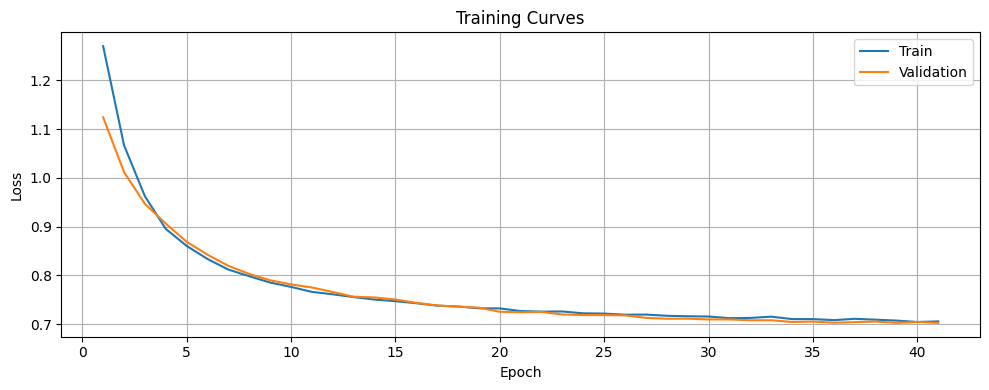

In [19]:
# One plot
plt.figure(figsize=(10, 4))
plt.plot(epochs, output1['train_losses'], label='Train')
plt.plot(epochs, output1['val_losses'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


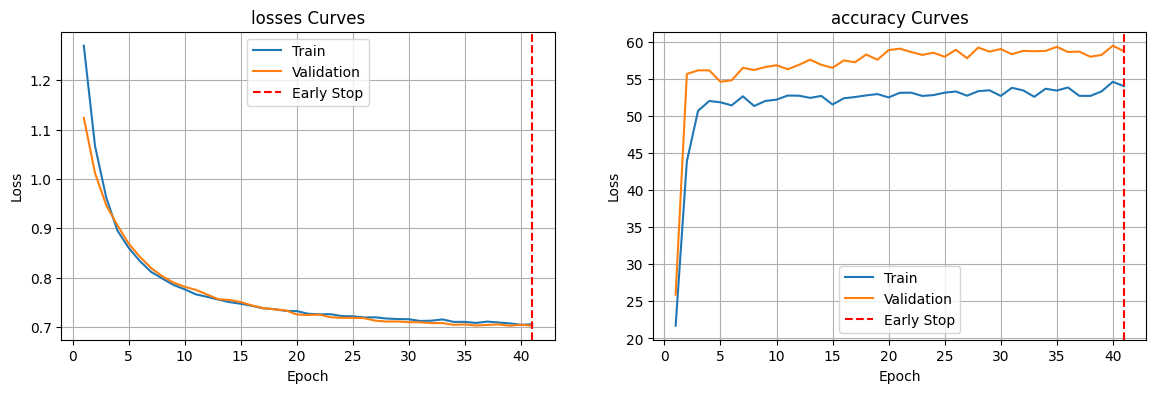

In [20]:
# Multiple plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

best_val_loss = min(output1['val_losses'])
best_epoch_idx = output1['val_losses'].index(best_val_loss)
trigger_epoch = epochs[best_epoch_idx]

axes[0].plot(epochs, output1['train_losses'], label='Train')  # left plot
axes[0].plot(epochs, output1['val_losses'], label='Validation')  # left plot
axes[0].axvline(x=trigger_epoch, color='r', linestyle='--', label=f'Early Stop')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('losses Curves')
axes[0].legend()
axes[0].grid(True)


axes[1].plot(epochs, output1['train_accs'], label='Train')  # right plot
axes[1].plot(epochs, output1['val_accs'], label='Validation')  # right plot
axes[1].axvline(x=trigger_epoch, color='r', linestyle='--', label=f'Early Stop')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('accuracy Curves')
axes[1].legend()
axes[1].grid(True)


### todo 2

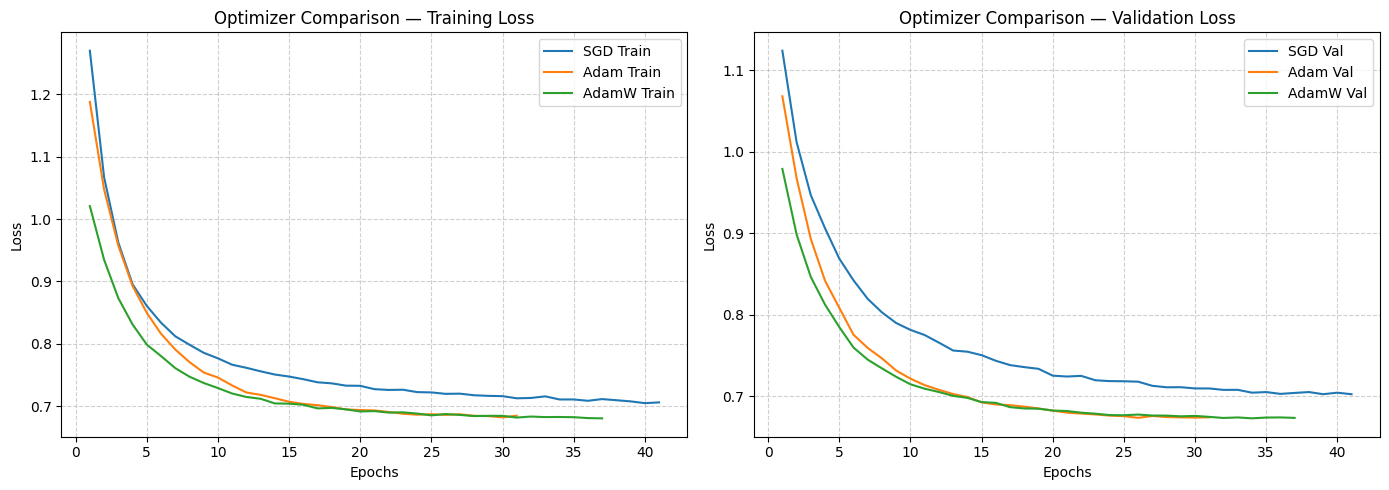

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Define a helper list to iterate through your data easily
experiments = [
    (output1, 'SGD'),
    (output2, 'Adam'),
    (output3, 'AdamW')
]

for data, label in experiments:
    # Dynamically create the x-axis based on the number of actual epochs run
    x_values = range(1, len(data['train_losses']) + 1)
    
    # Left Plot: Training Loss
    axes[0].plot(x_values, data['train_losses'], label=f'{label} Train')
    
    # Right Plot: Validation Loss
    axes[1].plot(x_values, data['val_losses'], label=f'{label} Val')

# Formatting the plots
for ax in axes:
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

axes[0].set_title('Optimizer Comparison — Training Loss')
axes[1].set_title('Optimizer Comparison — Validation Loss')

plt.tight_layout()
plt.show()

### TODO 3

1. the model is learning and have not over or under fit 
2. since i have used 5 epoches to save time i cannot answer that question but i would say epoch 4
3. i think adamw should have but since epoches are less we cannot say anything for sure